# MD Simulation of Torsionally Flexible Py-Et-Py in Acetonitrile

Our aims is to perform a molecular dynamics (MD) simulation of
torsionally flexible Py-Et-Py in acetonitrile. Because the molecule contains a rotatable
bond (2-3), particular attention was paid to the parametrization of its dihedral potential.

<figure>
  <img src="pics/struc.png" alt="Py_Et_Py" width="300" height="300">
  <figcaption>Ethyl-bridged bipyrene (Py_Et_Py).</figcaption>
</figure>

## 0. Generation and Parametrization of the Py-Et-Py Force Field

See jupyter notebook file within the `examples/molecular_dynamics/reparam_FF` folder for details on how this was done. A short summary of the performed steps are given below:

### 0.1 Quantum-mechanical calculations

The initial molecular geometry of Py-Et-Py was optimized using Gaussian at the
ωB97X-D/def2-SVP level of theory. In addition to the geometry optimization, a
quantum-mechanical (QM) torsional scan was performed around the rotatable bond of
interest.

This QM energy profile was subsequently used as a reference for parametrizing the
molecular-mechanics (MM) force field.

### 0.2 RESP charge calculation

RESP (Restrained Electrostatic Potential) charges were then calculated using VeloxChem.
These charges provide a simplified representation of the molecular charge distribution
for use in the molecular-mechanics force field.

In an MD simulation, the electrons are not explicitly represented. Instead, each atom is
assigned a partial charge, which allows the force field to approximate electrostatic
interactions between atoms.

### 0.3 Generation of the initial force-field parameters

Using the RESP charges and the molecular structure generated by VeloxChem, an initial
molecular-mechanics topology was generated.

The initial topology contains parameters describing the different interactions within
Py-Et-Py, including:

- atomic masses and partial charges,
- bond-stretching parameters,
- angle-bending parameters,
- dihedral/torsional parameters,
- and non-bonded interaction parameters.

The initial force field was then refined using the geometries and energies obtained from
the QM torsional scan.

### 0.4 Dihedral reparametrization

The torsional parameters were reparametrized by fitting the MM torsional energy profile
to the QM reference profile.

The general idea is:

    QM calculation
          |
          v
    QM torsional energy profile
          |
          | compare
          v
    MM torsional energy profile
          |
          v
    QM - MM difference
          |
          v
    Adjust force-field parameters
          |
          v
    New MM energy profile
          |
          v
    Repeat until satisfactory agreement is obtained

The fitting procedure involved adjusting the force constants (barriers) of the dihedral
terms and, where necessary, adding additional dihedral terms with different periodicities
and phases.

The objective was not necessarily to reproduce every QM energy value exactly, but to
obtain an MM torsional potential that provides a good representation of the QM
torsional energy profile.

### 0.5 Comparison before and after parametrization

Without dihedral reparametrization, the MM torsional energy profile was:

<img src="pics/0.png"  width="500" height="500">

After reparametrization, the MM torsional energy profile was:

<img src="pics/1.png"  width="500" height="500">

The best parametrization obtained by adding many dihedral angle terms was:

<img src="pics/2.png"  width="500" height="500">


# 1. Setting Up the MD Simulation

Once the Py-Et-Py force field had been parametrized, the next step is to construct the
system for the molecular dynamics simulation.

The simulation is performed in acetonitrile. This requires not only the topology of
Py-Et-Py, but also a description of the acetonitrile solvent and the interactions between
Py-Et-Py and the solvent molecules.

Before discussing the individual simulation commands, it is useful to understand the
main files used by GROMACS.

## 1.1 The main GROMACS input files

Three important files describing the molecular system are the `.top`, `.itp`, and `.gro`
files.

### `.gro` — molecular structure and coordinates

The `.gro` file contains the actual coordinates of the atoms in the system.

In other words, it tells GROMACS:

> Where is every atom located?

A `.gro` file typically contains:

- the number of atoms,
- the atom/residue information,
- the atom coordinates,
- and the dimensions of the simulation box.

A simplified example looks like:

    Py-Et-Py
    4
        1PYR    C1    1   0.100   0.200   0.300
        1PYR    C2    2   0.200   0.300   0.400
        1PYR    C3    3   0.300   0.400   0.500
        1PYR    C4    4   0.400   0.500   0.600
       2.00000   2.00000   2.00000

The coordinates in a `.gro` file are normally given in nanometers.

It is important to distinguish the `.gro` file from the force field:

    .gro  →  "Where are the atoms?"

    .top/.itp  →  "What are the atoms and how do they interact?"

The `.gro` file therefore describes a particular configuration of the system, whereas
the topology describes how the system should be treated energetically.

---

### `.itp` — molecular topology/parameters

The `.itp` file is an include topology file. It usually contains the molecular
topology and force-field parameters for a particular molecule or molecule type.

For example, the Py-Et-Py `.itp` file can contain information about:

- atoms,
- atomic masses,
- partial charges,
- bonds,
- angles,
- dihedrals,
- and sometimes other interaction terms.

A useful way to think about the `.itp` file is:

> "This is the recipe describing what Py-Et-Py is and how its atoms interact."

For example, an `[ atoms ]` section may contain information such as:

    [ atoms ]
    ; nr   type    resnr   residue   atom   cgnr   charge
      1    ...       1      PYR       C1      1     ...
      2    ...       1      PYR       C2      1     ...
      3    ...       1      PYR       C3      1     ...

The exact columns depend on the force-field/topology format being used.

The important idea is that each atom is assigned a force-field atom type and a partial
charge, while the other topology sections specify how atoms are connected and how their
interactions are calculated.

---

### `.top` — the complete system topology

The `.top` file describes the topology of the entire MD system.

For example, the system might contain:

    Py-Et-Py
        +
    many acetonitrile molecules

The `.top` file brings together the information required to simulate all of these
components.

It can therefore be thought of as the "master topology" for the simulation.

A typical structure might look conceptually like:

    [ defaults ]
        ...

    [ atomtypes ]
        ...

    #include "Py-Et-Py.itp"

    #include "acetonitrile.itp"

    [ system ]
        Py-Et-Py in acetonitrile

    [ molecules ]
        Py-Et-Py       1
        ACN          XXX

The `.top` file can include `.itp` files rather than containing every molecular
parameter directly. This makes the topology modular and easier to manage.

A useful analogy is:

    .itp = recipe for one component

    .top = complete recipe for the entire simulation system

    .gro = actual 3D arrangement of all atoms

---

# 1.2 How the files work together

These three files provide different pieces of information.

    ┌─────────────────────────────┐
    │           .gro              │
    │                             │
    │  Coordinates of the atoms   │
    │  + simulation box           │
    └──────────────┬──────────────┘
                   │
                   │
                   v
    ┌─────────────────────────────┐
    │           .top              │
    │                             │
    │  Complete system topology   │
    │  + included molecular       │
    │    topologies               │
    └──────────────┬──────────────┘
                   │
                   │ includes
                   v
    ┌─────────────────────────────┐
    │           .itp              │
    │                             │
    │  Molecular parameters       │
    │  Atoms                      │
    │  Bonds                      │
    │  Angles                     │
    │  Dihedrals                  │
    │  Charges                    │
    └─────────────────────────────┘

Together, these files tell GROMACS both:

1. what the system contains, and
2. how the atoms should interact.

For example, the `.gro` file might say that two atoms are currently 0.15 nm apart,
while the topology tells GROMACS whether those atoms are bonded and what potential
energy should be associated with that bond.

# 1.3 Understanding the sections (tags) in a topology file

GROMACS topology files are divided into sections. Each section starts with a keyword
enclosed in square brackets, for example:

    [ defaults ]

These sections are sometimes called "directives" or "topology blocks."

Each section has a specific purpose.

## `[ defaults ]`

The `[ defaults ]` section specifies general rules for the force field.

It tells GROMACS how certain types of interactions should be handled globally.

For example, it can define:

- the combination rule used for non-bonded interactions,
- whether certain interactions are generated automatically,
- and other general force-field settings.

A typical example is:

    [ defaults ]
    ; nbfunc    comb-rule    gen-pairs    fudgeLJ    fudgeQQ
      1         2            yes          0.5        0.8333

The exact values depend on the force field being used.

For someone new to MD, the main thing to remember is:

> `[ defaults ]` defines some global rules that affect how the force field is
> interpreted.

It does not describe one particular atom or bond.

---

## `[ atomtypes ]`

The `[ atomtypes ]` section defines the available force-field atom types.

An atom type is not necessarily the same thing as a chemical element.

For example, two carbon atoms can have different atom types if they occur in different
chemical environments.

An atom type can define properties such as:

- atomic mass,
- Lennard-Jones parameters,
- and other information used to calculate non-bonded interactions.

Conceptually:

    atom type
        |
        +---- mass
        |
        +---- van der Waals parameters
        |
        +---- other force-field properties

The `[ atoms ]` section can then assign one of these atom types to each atom in the
molecule.

This distinction is important:

    Element:
        C

    Atom type:
        a particular force-field representation of a carbon atom

The force field uses the atom type because atoms of the same element can behave
differently depending on their chemical environment.

---

## `[ moleculetype ]`

The `[ moleculetype ]` section defines a molecular species.

For example:

    [ moleculetype ]
    ; name       nrexcl
      Py-Et-Py    3

This tells GROMACS that the following topology information describes a particular
molecule.

The `nrexcl` parameter specifies how certain short-range non-bonded interactions between
atoms connected through the molecular topology are treated.

For the moment, it is sufficient to think of `[ moleculetype ]` as:

> "The following topology information describes one type of molecule."

---

## `[ atoms ]`

The `[ atoms ]` section defines the individual atoms in the molecule.

It typically specifies information such as:

- atom number,
- atom type,
- residue number,
- residue name,
- atom name,
- charge group,
- mass,
- and partial charge.

For example:

    [ atoms ]
    ; nr  type  resnr  residue  atom  cgnr  charge  mass
      1   C1      1      PY      C1     1    ...    ...
      2   C2      1      PY      C2     1    ...    ...
      3   C3      1      PY      C3     1    ...    ...

The `[ atoms ]` section therefore connects the actual atoms in your molecule to the
force-field parameters.

---

## `[ bonds ]`

The `[ bonds ]` section describes which atoms are connected by covalent bonds and how
those bonds behave.

Conceptually:

    atom 1 ───────── atom 2

The force field assigns an energy penalty when the bond is stretched or compressed away
from its preferred geometry.

A simplified representation is:

    E_bond = force constant × (bond length − equilibrium length)²

Thus, the bond parameters determine both the preferred bond length and how strongly the
system resists changing that bond length.

---

## `[ angles ]`

The `[ angles ]` section describes three-atom bond angles:

    atom 1
       \
        atom 2
       /
    atom 3

The force field assigns an energy penalty when this angle deviates from its equilibrium
value.

For example, an angle parameter might specify:

    equilibrium angle = 120°

meaning that the force field considers an angle near 120° energetically favorable.

---

## `[ dihedrals ]`

The `[ dihedrals ]` section is particularly important for the present study because
Py-Et-Py contains a torsionally flexible bond.

A dihedral involves four atoms:

    1 — 2 — 3 — 4
        ↑   ↑
        └───┘
       central bond

The dihedral angle describes rotation around the central 2–3 bond.

The dihedral potential determines how the energy changes as this bond rotates.

Here, the QM torsional scan was used to determine whether the original
dihedral parameters were able to reproduce the QM torsional energy profile.

Additional dihedral terms were introduced where necessary to improve the agreement
between the MM and QM profiles.

---

## `[ pairs ]`

The `[ pairs ]` section can define specific pairwise interactions between atoms that
are treated separately from the standard non-bonded interactions.

In many force fields, these are related to 1–4 interactions, meaning interactions
between atoms separated by three covalent bonds:

    1 — 2 — 3 — 4
    \_______________/
          1–4

The exact treatment depends on the force field and the settings specified in
`[ defaults ]`.

---

## `[ exclusions ]`

The `[ exclusions ]` section specifies atom pairs for which certain non-bonded
interactions should be excluded.

This is necessary because atoms that are directly connected through the molecular
topology should not always interact through the normal non-bonded potential in the same
way as two atoms that are far apart.

---

## `[ system ]`

The `[ system ]` section provides a descriptive name for the complete simulation system.

For example:

    [ system ]
    Py-Et-Py in acetonitrile

This is mainly a human-readable description.

---

## `[ molecules ]`

The `[ molecules ]` section specifies how many copies of each molecular species are
present in the simulation.

For example:

    [ molecules ]
    Py-Et-Py       1
    ACN          500

This would mean that the simulation contains:

- 1 Py-Et-Py molecule
- 500 acetonitrile molecules

The actual numbers depend on the size and concentration of the simulated system.

# 1.4 Summary of the topology sections

For a beginner, the most useful way to remember the sections is:

    [ defaults ]
        Global rules for interpreting the force field

    [ atomtypes ]
        Definitions of force-field atom types

    [ moleculetype ]
        Definition of a molecular species

    [ atoms ]
        Which atoms make up the molecule and their charges/types

    [ bonds ]
        Covalent bond parameters

    [ angles ]
        Bond-angle parameters

    [ dihedrals ]
        Torsional/rotational parameters

    [ pairs ]
        Specific pairwise interactions, often related to 1–4 interactions

    [ exclusions ]
        Non-bonded interactions that should be excluded

    [ system ]
        Name/description of the complete system

    [ molecules ]
        Number of copies of each molecular species

# 1.5 Putting everything together

At this point, the overall workflow can be summarized as follows:

    QM calculations
        │
        ├── optimized geometry
        │
        ├── torsional scan
        │
        └── electrostatic potential
                 │
                 v
            RESP charges
                 │
                 v
        Initial force field
                 │
                 v
       QM/MM torsional comparison
                 │
                 v
        Dihedral reparametrization
                 │
                 v
       Final Py-Et-Py force field
                 │
                 v
    ┌──────────────────────────────┐
    │       MD system setup        │
    │                              │
    │  Py-Et-Py + acetonitrile     │
    └──────────────────────────────┘
                 │
                 ├── .itp → molecular parameters
                 │
                 ├── .top → complete system topology
                 │
                 └── .gro → atom coordinates
                 │
                 v
           MD simulation

# 1.6 Preparing the Files and Creating the Simulation Box

Before running the MD simulation, the molecular topology and coordinates of both
Py-Et-Py and the acetonitrile (ACN) solvent need to be combined into one simulation
system.

The general workflow is:

    Py_Et_Py.gro
          |
          v
    Create simulation box
          |
          v
       box.gro
          |
          +------ ACN.gro
          |
          v
    Insert ACN molecules
          |
          v
       box2.gro
          |
          v
    Py-Et-Py + ACN simulation system


## 1.6.1 Acetonitrile topology and structure files

For acetonitrile, we use the GAFF-ESP-2018 force field. The required files were
downloaded beforehand and can be found in the corresponding acetonitrile directory.

The directory contains the topology and coordinate files for acetonitrile. We need:

    ACN.top
    ACN.gro

The `.gro` file contains the coordinates of one acetonitrile molecule, while the
`.top` file contains the topology and force-field parameters describing that molecule.

Because the acetonitrile topology will be included in our main system topology, we
rename the topology file from:

    ACN.top

to:

    ACN.itp

The `.itp` extension is useful here because the file will be included as a molecular
topology inside our main `topol.top` file rather than being used as the complete system
topology.

We therefore have:

    Py_Et_Py.itp    → topology of one Py-Et-Py molecule
    ACN.itp         → topology of one acetonitrile molecule
    ACN.gro         → coordinates of one acetonitrile molecule


## 1.6.2 Constructing the system topology

We now combine the Py-Et-Py and acetonitrile molecular topologies into one system
topology called:

    topol.top

The important point is that there should only be **one `[ defaults ]` section and one
`[ atomtypes ]` section in the final topology**.

The individual `.itp` files should therefore not independently define these global
sections if they are going to be included in `topol.top`.

### Why does this matter?

The `[ defaults ]` and `[ atomtypes ]` sections define force-field information that
applies globally.

If both `Py_Et_Py.itp` and `ACN.itp` contain their own copies of these sections, GROMACS
can encounter duplicate or conflicting definitions.

Therefore, the final topology is organized approximately as:

    topol.top
    │
    ├── [ defaults ]
    │
    ├── [ atomtypes ]
    │
    ├── #include "Py_Et_Py.itp"
    │
    ├── #include "ACN.itp"
    │
    ├── [ system ]
    │
    └── [ molecules ]


### Combining the atom types

The atom types from the individual force-field files are collected into the
`[ atomtypes ]` section of `topol.top`.

When doing this, it is important to check that there are no duplicate atom-type names.

For example, if both files contain:

    c3

then the two definitions need to be checked carefully. Two different definitions
cannot simply be assigned to the same atom type without checking that they are
compatible.

The comments in the original GAFF-ESP-2018 atom-type file can also be removed if they
are not needed. Anything following a semicolon (`;`) in a GROMACS topology is treated
as a comment and is therefore ignored by GROMACS.

For example:

    c3   c3   0.00000   0.00000   A   3.39771e-01   4.51035e-01 ; some comment

is interpreted by GROMACS as the parameter information before the semicolon. The text
after `;` is only a comment for the user.


## 1.6.3 The `topol.top` file

The resulting `topol.top` file should look approximately like this:

    [ defaults ]
    ; nbfunc        comb-rule       gen-pairs        fudgeLJ   fudgeQQ
    1               2               yes             0.500000  0.833333

    [ atomtypes ]
    ; name   bond_type     mass     charge   ptype   sigma         epsilon
      c3     c3            0.00000  0.00000   A     3.39771e-01   4.51035e-01
      hc     hc            0.00000  0.00000   A     2.60018e-01   8.70272e-02
      c1     c1            0.00000  0.00000   A     3.39967e-01   8.78640e-01
      n1     n1            0.00000  0.00000   A     3.25000e-01   7.11280e-01
      ca     ca            0.00000  0.00000   A     3.31521e-01   4.13379e-01
      cc     cc            0.00000  0.00000   A     3.31521e-01   4.13379e-01
      cd     cd            0.00000  0.00000   A     3.31521e-01   4.13379e-01
      ha     ha            0.00000  0.00000   A     2.62548e-01   6.73624e-02

    #include "Py_Et_Py.itp"
    #include "ACN.itp"

    [ system ]
    Py_Et-Py in ACN

    [ molecules ]
    ; Compound        nmols
    PYR               1
    ACN               2500


### Understanding `#include`

The lines

    #include "Py_Et_Py.itp"
    #include "ACN.itp"

tell GROMACS to insert the contents of these files at that location.

This is similar to an `import` statement in programming.

Instead of putting the entire Py-Et-Py topology directly inside `topol.top`, we keep it
in a separate file and tell GROMACS where to find it.

This makes the topology easier to organize and modify.

### The `[ molecules ]` section

The `[ molecules ]` section tells GROMACS how many copies of each molecular species
are present in the simulation.

Here:

    [ molecules ]
    PYR    1
    ACN    2500

means that the simulation contains:

    1 × Py-Et-Py
    2500 × acetonitrile

At this stage, the number of ACN molecules is only a placeholder. The final number will
be determined from the desired density of acetonitrile and the volume of the simulation
box.


# 1.6.4 Creating the simulation box

We next create a cubic simulation box around the Py-Et-Py molecule.

We use the GROMACS command:

    gmx editconf -f Py_Et_Py.gro -bt cubic -box 5 5 5 -o box.gro -center 2.5 2.5 2.5

The `gmx editconf` command is used to modify or generate the configuration of a
molecular system, including its simulation box.

The options used here are:

    gmx editconf

Runs the GROMACS `editconf` program.

    -f Py_Et_Py.gro

Specifies the input coordinate file.

Here, the input is the Py-Et-Py structure:

    Py_Et_Py.gro

    -bt cubic

Specifies that the simulation box should be cubic.

Other box shapes are possible, but a cubic box is convenient for this simulation.

    -box 5 5 5

Sets the box dimensions to:

    5 nm × 5 nm × 5 nm

GROMACS uses nanometers for distances in these coordinate files and commands.

Therefore, the volume of this box is:

    V = 5 × 5 × 5 nm³
      = 125 nm³

    -o box.gro

Specifies the output coordinate file.

The newly generated structure will therefore be written to:

    box.gro

    -center 2.5 2.5 2.5

Places the center of the Py-Et-Py molecule at the center of the simulation box.

Because the box extends from approximately 0 to 5 nm in each direction, its center is:

    (2.5, 2.5, 2.5) nm

### Summary of the command

The command can therefore be read in plain English as:

> Take `Py_Et_Py.gro`, put the molecule in the center of a 5 × 5 × 5 nm³ cubic box,
> and save the resulting structure as `box.gro`.

After running the command:

    gmx editconf -f Py_Et_Py.gro -bt cubic -box 5 5 5 \
        -o box.gro -center 2.5 2.5 2.5

the resulting `box.gro` file can be inspected visually using VMD.

![Initial Py-Et-Py simulation box](pics/box.png)


## 1.6.5 Visualizing the box with VMD

The resulting structure can be opened in VMD to check that the molecule is positioned
correctly inside the simulation box.

A VMD style script called `box.sh` is also provided. This script can be sourced from
the VMD Tk Console to apply the desired visualization settings, such as atom colors,
background, and representation style.

This visualization step is useful because it allows us to check for obvious problems
before continuing with the simulation setup.


# 1.6.6 Determining the number of acetonitrile molecules

The next step is to fill the simulation box with acetonitrile.

The number of ACN molecules should be chosen so that the resulting system has
approximately the desired density.

For liquid acetonitrile, we use:

    density = 0.7822 g/mL

The molar mass of acetonitrile is approximately:

    M = 41.05 g/mol

The number of molecules can be calculated from:

In [1]:
import numpy as np
import scipy.constants as sc

# molar mass of ACN / g/mol
M = 41.05

# density / g/mL
rho = 0.7822 

# avogadros constant
Na = sc.Avogadro

# legth of the box in / m 
L = 5e-9
# volume in m^3
V = L**3
# convert to mL
V = V*10**6

# calculate the required number of ACN molecules
N = (rho*Na*V)/M

print(f"N = {N}")

N = 1434.3844404604142


The calculation gives approximately:

    N ≈ 1434 molecules

Therefore, approximately 1434 acetonitrile molecules are required to obtain the target
density in a 5 × 5 × 5 nm³ box.

The actual number of molecules must be an integer, so we use:

    N_ACN = 1434


# 1.6.7 Inserting acetonitrile molecules

We can now insert the ACN molecules into the simulation box using:

    gmx insert-molecules -f box.gro -ci ACN.gro -nmol 1434 -o box2.gro -try 10000

The options are:

    gmx insert-molecules

Runs the GROMACS program used to insert copies of a molecule into an existing
configuration.

    -f box.gro

Specifies the existing structure into which the molecules should be inserted.

In this case, this is the box containing Py-Et-Py.

    -ci ACN.gro

Specifies the coordinate file of the molecule that should be inserted.

Here, one ACN molecule is defined by:

    ACN.gro

GROMACS uses this structure as the template and attempts to insert multiple copies of it.

    -nmol 1434

Requests that 1434 copies of the ACN molecule be inserted.

    -o box2.gro

Specifies the output coordinate file.

The final structure will therefore be written to:

    box2.gro

    -try 10000

Specifies the maximum number of insertion attempts.

This is useful because molecules cannot simply be placed at arbitrary positions. GROMACS
checks whether the newly inserted molecule overlaps too strongly with atoms that are
already present in the system.

If an attempted insertion produces an unacceptable overlap, GROMACS tries another
position.

Increasing the number of attempts gives GROMACS more opportunities to successfully
place all the solvent molecules, particularly when the box becomes crowded.


### In plain language

The command:

    gmx insert-molecules -f box.gro -ci ACN.gro -nmol 1434 -o box2.gro -try 10000

means:

> Take the box containing Py-Et-Py, and try to fill it with 1434 copies of the
> acetonitrile molecule defined in `ACN.gro`. Try up to 10,000 different placements
> when necessary, and save the resulting system as `box2.gro`.

The final system therefore contains approximately:

    1 Py-Et-Py molecule
    +
    1434 acetonitrile molecules

The resulting `box2.gro` file can again be opened in VMD to visually inspect the
system.

At this stage, we should see Py-Et-Py surrounded by acetonitrile molecules throughout
the simulation box. We can use Gromacs to look at the box again: 

![Initial Py-Et-Py simulation box](pics/box2.png)

# 1.6.8 Important distinction: topology vs coordinates

It is useful to emphasize that `insert-molecules` changes the **coordinates**, not the
force-field parameters.

Before insertion:

    box.gro
        ↓
    Py-Et-Py coordinates

After insertion:

    box2.gro
        ↓
    Py-Et-Py coordinates
    +
    ACN coordinates

The topology still needs to tell GROMACS that the system contains:

    1 × PYR
    1434 × ACN

Therefore, after determining the final number of molecules, the `[ molecules ]` section
of `topol.top` should be updated accordingly:

    [ molecules ]
    ; Compound        nmols
    PYR               1
    ACN               1434

The coordinate file and topology must agree with one another: if `box2.gro` contains
1434 ACN molecules but `topol.top` specifies a different number, GROMACS will report an
inconsistency when preparing the simulation.

# 1.6.9 Summary

The complete preparation procedure so far is:

    1. Obtain ACN.itp and ACN.gro
              |
              v
    2. Combine Py-Et-Py and ACN atom types
       into topol.top
              |
              v
    3. Include Py_Et_Py.itp and ACN.itp
              |
              v
    4. Create a 5 × 5 × 5 nm³ simulation box
              |
              v
       gmx editconf
              |
              v
           box.gro
              |
              v
    5. Calculate the number of ACN molecules
       required for the desired density
              |
              v
           N ≈ 1434
              |
              v
    6. Insert ACN molecules
              |
              v
       gmx insert-molecules
              |
              v
           box2.gro
              |
              v
    7. Update [ molecules ] in topol.top
              |
              v
       1 Py-Et-Py + 1434 ACN

The resulting `box2.gro` contains the three-dimensional coordinates of the complete
system, while `topol.top` contains the information GROMACS needs to calculate the
forces and energies between all atoms.

# 1.9 Energy Minimization

Before starting the molecular dynamics simulation, the initial structure needs to be
energy-minimized.

The coordinates generated during system preparation are not necessarily at a
physically reasonable minimum-energy configuration. In particular, the insertion of
many acetonitrile molecules into the box can produce unfavorable contacts or atoms that
are initially too close to one another.

Energy minimization is therefore used to remove these very unfavorable configurations
before starting the MD simulation.

## 1.9.1 What is energy minimization?

In molecular dynamics, the atoms experience forces that are related to the gradient of
the potential energy:

    force = - gradient of potential energy

Therefore, if the system has a very high-energy configuration, there will generally be
large forces acting on some atoms.

Energy minimization moves the atoms in the direction that decreases the potential
energy.

Conceptually:

    Potential energy
          ^
          |       *
          |      / \
          |     /   \
          |    /     \
          |   /       \____
          |__/              \____
          |
          +--------------------------> molecular configuration

The minimization procedure tries to move the system "downhill" toward a local minimum
of the potential-energy surface.

Importantly, this is **not yet a molecular dynamics simulation**. The atoms are not
being propagated through time according to their velocities. Instead, the coordinates
are being adjusted to find a lower-energy configuration.

This is particularly useful here because the initial solvent configuration was created
by inserting many ACN molecules into the box. Some of these molecules may initially be
too close together, resulting in very large repulsive forces.

---

## 1.9.2 Preparing the minimization with `grompp`

First, a directory for the minimization (`min`) was created:

    MD/
    ├── min/
    ├── ...
    ├── box2.gro
    ├── topol.top
    └── min.mdp

The GROMACS preprocessor `grompp` was then used to combine the molecular coordinates,
topology, and minimization settings into an input file for the MD engine.

The command was:

    gmx grompp -f min.mdp -c box2.gro -p topol.top -o min/min

### What is `grompp`?

`grompp` stands for **GROMACS preprocessor**.

It takes several input files and prepares them for the actual simulation program,
`mdrun`.

In simplified terms:

    .mdp + .gro + .top
              |
              v
           grompp
              |
              v
        simulation input
              |
              v
           mdrun

The options in the command are:

    gmx grompp

Run the GROMACS preprocessing program.

    -f min.mdp

Specifies the molecular-dynamics parameter file (`.mdp`).

Here, `min.mdp` contains the settings for the energy minimization.

    -c box2.gro

Specifies the input coordinate file.

`box2.gro` contains the Py-Et-Py molecule surrounded by the inserted acetonitrile
molecules.

    -p topol.top

Specifies the system topology.

This tells GROMACS what molecules are present and which force-field parameters should
be used to calculate the energies and forces.

    -o min/min

Specifies the name and location of the output file produced by `grompp`.

The resulting file is used by `mdrun` to perform the actual minimization.

---

# 1.9.3 The minimization parameters

The minimization settings are specified in `min.mdp`.

The file used here contains:

    ; Run parameters
    integrator            = steep
    nsteps                = 100000
    emstep                = 0.1
    emtol                 = 50

    ; Neighbor searching
    cutoff-scheme          = Verlet
    ns_type                = grid
    nstlist                = 10
    rcoulomb               = 1.2
    rvdw                   = 1.2
    rlist                  = 1.2

    ; Electrostatics
    coulombtype            = PME
    pme_order              = 4
    fourierspacing         = 0.12

    ; Periodic boundary conditions
    pbc                    = xyz


## Run parameters

### `integrator = steep`

This specifies the minimization algorithm.

    integrator = steep

means that the **steepest-descent** algorithm is used.

Steepest descent is a common method for energy minimization. At each step, the
coordinates are changed in a direction that reduces the potential energy.

It can be thought of as walking downhill:

    High energy
         *
        / \
       /   \
      /     \
     ↓       \
    ↓         \
   ↓           \____
                   *
                minimum

The goal is to remove large forces and unfavorable contacts from the initial structure.

---

### `nsteps = 100000`

    nsteps = 100000

sets the maximum number of minimization steps.

This does **not** necessarily mean that 100,000 steps will actually be performed.

The minimization can stop earlier if the convergence criterion specified by `emtol` is
reached.

Thus:

    nsteps = maximum number of allowed steps

rather than:

    nsteps = number of steps that will definitely be performed


### `emstep = 0.1`

    emstep = 0.1

sets the initial step size used by the steepest-descent minimization.

It controls how far the coordinates can be moved during a minimization step.

If the step is too large, the minimization can become unstable or inefficient. If it is
too small, convergence can become unnecessarily slow.


### `emtol = 50`

    emtol = 50

specifies the convergence criterion for the minimization.

The minimization stops when the maximum force in the system is below the specified
tolerance.

Therefore, in this case, the minimization aims to reach:

    maximum force < 50 kJ mol^-1 nm^-1

or to reach the maximum number of steps first.

This is an important distinction: **energy minimization is considered converged based
on the forces, rather than simply because the potential energy has stopped changing
visibly.**

---

# 1.9.4 Neighbor searching

Molecular simulations contain many atoms, so calculating every possible pairwise
interaction would be computationally expensive.

For example, with thousands of atoms there are millions of possible atom pairs.

GROMACS therefore uses neighbor lists and cutoffs to efficiently determine which atoms
need to be considered for short-range interactions.

The relevant settings are:

    cutoff-scheme = Verlet
    ns_type       = grid
    nstlist       = 10
    rcoulomb      = 1.2
    rvdw          = 1.2
    rlist         = 1.2


### `cutoff-scheme = Verlet`

    cutoff-scheme = Verlet

specifies the Verlet neighbor-list scheme.

This is the standard modern approach used by GROMACS for efficiently determining
short-range interacting pairs.


### `ns_type = grid`

    ns_type = grid

specifies the method used to construct the neighbor list.

The simulation box is divided conceptually into regions or grid cells. GROMACS can then
quickly identify nearby atoms rather than checking every atom against every other atom.

> Note: in modern GROMACS versions, `ns_type` is generally obsolete because the
> Verlet scheme automatically handles the appropriate neighbor searching. If GROMACS
> warns that this option is ignored, it can simply be removed from the `.mdp` file.


### `nstlist = 10`

    nstlist = 10

specifies how frequently the neighbor list is updated.

A value of 10 means that the neighbor list is updated every 10 steps.

During energy minimization, atoms move, so the list of nearby atoms needs to be updated
periodically.


### `rcoulomb = 1.2`

    rcoulomb = 1.2

sets the short-range Coulomb interaction cutoff to 1.2 nm.

Electrostatic interactions are split into short-range and long-range contributions.
Interactions within the short-range cutoff are handled directly, while longer-range
electrostatic interactions are treated using PME.


### `rvdw = 1.2`

    rvdw = 1.2

sets the short-range van der Waals cutoff to 1.2 nm.

Van der Waals interactions become weaker with increasing distance, so a cutoff is used
to avoid explicitly calculating interactions between atoms that are very far apart.


### `rlist = 1.2`

    rlist = 1.2

specifies the neighbor-list cutoff.

The neighbor list contains atom pairs within the specified distance that may need to be
considered for short-range interactions.


# 1.9.5 Electrostatics

The electrostatic interactions are treated using:

    coulombtype = PME

where PME stands for **Particle Mesh Ewald**.

Electrostatic interactions are particularly important in this system because both
Py-Et-Py and acetonitrile contain atoms with partial charges.

Electrostatic interactions are long-ranged, meaning that charged atoms can interact
even when they are relatively far apart.

PME provides an efficient way of calculating these long-range electrostatic
interactions in a periodically repeated simulation box.

In simplified terms:

    Short-range electrostatics
            ↓
      calculated directly

    Long-range electrostatics
            ↓
           PME


### `pme_order = 4`

    pme_order = 4

specifies the interpolation order used by the PME calculation.

The value of 4 corresponds to fourth-order interpolation.

For the purposes of this simulation, this controls how the electrostatic information
is represented on the PME grid.


### `fourierspacing = 0.12`

    fourierspacing = 0.12

specifies the approximate spacing of the Fourier grid used by PME, in nm.

A smaller spacing generally gives a finer grid and potentially higher accuracy, but
requires more computational effort.


# 1.9.6 Periodic boundary conditions

Finally:

    pbc = xyz

specifies periodic boundary conditions in all three spatial directions.

This means that the simulation box is treated as though it is surrounded by identical
copies of itself:

                    ┌─────────────┐
                    │             │
                    │  simulation │
                    │     box     │
                    │             │
                    └─────────────┘
                         ↓
                  identical boxes
                  surround it in
                  all directions

If an atom leaves the simulation box through one side, it effectively re-enters through
the opposite side.

This allows a finite simulation box to represent bulk liquid rather than a small
isolated cluster of molecules.

---

# 1.9.7 Running the minimization

Once `grompp` has successfully prepared the input, the actual energy minimization is
performed using `mdrun`.

The command is:

    gmx mdrun -v -deffnm min/min

### `gmx mdrun`

`mdrun` is the GROMACS program that actually performs the calculation.

While `grompp` prepares the simulation, `mdrun` performs it.

In this case, `mdrun` reads the input generated by `grompp` and performs the energy
minimization.

### `-v`

The `-v` option means **verbose output**.

It provides additional information about the progress of the calculation while
`mdrun` is running.

### `-deffnm min/min`

This specifies the default filename prefix for the output files.

Using:

    -deffnm min/min

causes the output files to be written with the `min/min` prefix.

For example, this can produce files such as:

    min/min.log
    min/min.edr
    min/min.gro
    min/min.tpr

The exact set of files depends on the GROMACS version and options used.


# 1.9.8 Checking the potential energy

After the minimization has finished, the potential energy can be extracted from the
energy file using:

    gmx energy -f min/min.edr -o min/ener.xvg

GROMACS will present a list of available quantities stored in the energy file.

The number corresponding to:

    Potential

is then selected.

In the command-line interaction this is indicated by:

    (10)

assuming that `Potential` is item 10 in the list.

The resulting file:

    min/ener.xvg

contains the potential energy information and can be plotted to inspect the
minimization.

The potential energy should generally decrease as the minimization proceeds:

    Potential energy
          ^
          |
          |\
          | \
          |  \
          |   \____
          |        \______
          |
          +--------------------> minimization step

The exact shape depends on the system and force field.

---

# 1.9.9 Did the minimization converge?

The important question is not simply whether `mdrun` finished without an error.

We want to know whether the minimization actually **converged**.

GROMACS reports information about the final state of the minimization in the output.
In particular, the final maximum force and the number of minimization steps should be
checked. Let's check if it converged!



Text(0.5, 0, 'step')

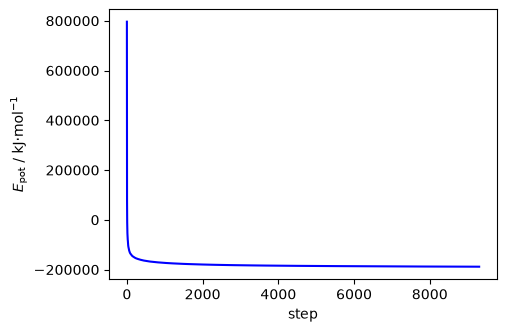

In [4]:
from matplotlib import pyplot as plt
data = np.loadtxt('MD/min/ener.xvg', skiprows=24)
step = data[:,0]
Epot = data[:,1]
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.plot(step, Epot, '-b')
ax.set_ylabel(r'$E_{\text{pot}}$ / kJ$\cdot$mol$^{-1}$')
ax.set_xlabel(r'step')

## 1.9.10 Summary of the commands

The complete minimization procedure was:

    # Prepare the minimization
    gmx grompp \
        -f min.mdp \
        -c box2.gro \
        -p topol.top \
        -o min/min

    # Run the minimization
    gmx mdrun \
        -v \
        -deffnm min/min

    # Extract the potential energy
    gmx energy \
        -f min/min.edr \
        -o min/ener.xvg

The first command **prepares** the calculation, the second command **performs** the
calculation, and the third command **extracts energy data** so that the result can be
checked.

Once the minimization has converged, the minimized structure can be used as the starting
configuration for the subsequent equilibration stages. The resulting minimized box is located within the `min` directory and called `min.gro`:

![Initial Py-Et-Py simulation box](pics/min.png)


# 2.0 Equilibration: NVT

After energy minimization, the system has a reasonable starting geometry with any severe atomic overlaps or unfavorable contacts removed. However, the atoms are not yet moving with the desired thermal distribution. Before starting the production simulation, we therefore need to **equilibrate the system**.

The first equilibration step is performed in the **NVT ensemble**, where:

* **N** = number of particles is constant
* **V** = volume is constant
* **T** = temperature is controlled and kept close to the target temperature

In this simulation, the target temperature is **298.15 K**. During NVT equilibration, the simulation box is kept at the same size as after energy minimization, while the thermostat gradually establishes the desired temperature distribution.

---

## 2.0.1 Preparing the NVT simulation

First, we prepare the NVT simulation using `gmx grompp`:

```bash
gmx grompp -f nvt.mdp -c min/min.gro -p topol.top -o nvt/nvt
```

The `gmx grompp` command reads the simulation settings, coordinates, and topology and combines them into the input needed by `gmx mdrun`.

Here:

* `-f nvt.mdp` specifies the **MD parameter file** containing the NVT simulation settings.
* `-c min/min.gro` uses the **energy-minimized structure** as the starting configuration.
* `-p topol.top` provides the system topology.
* `-o nvt/nvt` defines the output filename prefix. GROMACS will therefore place files such as `nvt.tpr`, `nvt.edr`, and `nvt.log` in the `nvt` directory.

The important point is that we start the NVT simulation from the **minimized structure**, rather than from the original structure containing the potentially unfavorable contacts.

---

## 2.0.2 NVT parameter file

The NVT simulation is controlled by the following `nvt.mdp` file:

```text
; Run parameters
integrator            = md          ; leap-frog integrator
dt                    = 0.001       ; time step length (ps)
nsteps                = 200000      ; number of steps
continuation          = no          ; generate new velocities

; Output control
nstenergy             = 100         ; steps between saving energies
nstlog                = 100         ; steps between saving log information

; Bond parameters
constraint_algorithm  = lincs
constraints            = h-bonds    ; constrain bonds involving hydrogen
lincs_iter             = 1          ; number of LINCS iterations
lincs_order            = 4          ; order of the LINCS expansion

; Neighbor searching
rlist                  = 1.2        ; short-range neighbor-list cutoff (nm)
rcoulomb               = 1.2        ; short-range electrostatic cutoff (nm)
rvdw                   = 1.2        ; short-range van der Waals cutoff (nm)

; Electrostatics
coulombtype            = PME        ; Particle Mesh Ewald
pme_order              = 4          ; interpolation order
fourierspacing         = 0.16       ; FFT grid spacing (nm)

; Temperature coupling
tcoupl                 = v-rescale   ; temperature coupling algorithm
tc-grps                = system      ; couple the entire system
tau_t                  = 0.1         ; temperature coupling time (ps)
ref_t                  = 298.15      ; target temperature (K)

; Pressure coupling
pcoupl                 = no          ; pressure is not controlled in NVT

; Periodic boundary conditions
pbc                    = xyz         ; 3-D periodic boundary conditions

; Dispersion correction
DispCorr               = EnerPres     ; correction for truncated vdW interactions

; Velocity generation
gen_vel                = yes
gen_temp               = 298.15      ; initial temperature (K)
gen_seed               = -1          ; generate a random seed
```

### Run parameters

```text
integrator = md
```

Here, `md` tells GROMACS to perform molecular dynamics. The atoms are propagated through time according to Newton's equations of motion.

```text
dt = 0.001
```

This is the **time step**, given in ps. A value of `0.001 ps` corresponds to **1 fs**.

At every MD step, GROMACS calculates the forces acting on the atoms and uses them to determine their new positions and velocities.

```text
nsteps = 200000
```

This specifies the maximum number of MD steps.

With a time step of 0.001 ps and 200,000 steps, the total simulation time is:

$$
200000 \times 0.001\ \mathrm{ps} = 200\ \mathrm{ps}
$$

Therefore, this NVT equilibration runs for **200 ps**.

```text
continuation = no
```

This indicates that this is a new MD simulation rather than a continuation from a previous MD run. In particular, we generate a new set of initial velocities below.

---

## 2.0.3 Output control

```text
nstenergy = 100
nstlog    = 100
```

These parameters control how frequently information is written to the output files.

`nstenergy = 100` means that energy-related information is saved every 100 MD steps. Since each step is 0.001 ps, this corresponds to:

$$
100 \times 0.001 = 0.1\ \mathrm{ps}
$$

Similarly, `nstlog = 100` means that information is written to the log file every 0.1 ps.

Saving data frequently is useful for analysing the simulation, although it also produces larger output files.

---

## 2.0.4 Bond constraints and LINCS

```text
constraint_algorithm = lincs
constraints           = h-bonds
lincs_iter            = 1
lincs_order            = 4
```

Molecular bonds involving hydrogen atoms vibrate very quickly. If these vibrations were explicitly simulated, we would need to use a very small time step.

Instead, we constrain the hydrogen-containing bonds and therefore use a 1 fs time step.

`constraints = h-bonds` tells GROMACS to constrain bonds involving hydrogen.

`lincs` is the algorithm used to enforce these constraints. It prevents the constrained bonds from deviating significantly from their specified equilibrium lengths.

The parameters

```text
lincs_iter = 1
lincs_order = 4
```

control the accuracy of the LINCS constraint calculation. In most ordinary systems, the default settings are sufficient, but they can become important for highly constrained or strongly distorted structures.

---

## 2.0.5 Neighbor searching and short-range interactions

```text
rlist    = 1.2
rcoulomb = 1.2
rvdw     = 1.2
```

During an MD simulation, every atom interacts with many other atoms. Calculating every possible pair of atoms would be unnecessarily expensive, especially for a system containing thousands of solvent molecules.

GROMACS therefore uses a **neighbor list** to keep track of nearby atoms.

The `rlist` value defines the distance used for constructing this list, while `rcoulomb` and `rvdw` define the short-range cutoffs for electrostatic and van der Waals interactions, respectively.

Here, all three distances are 1.2 nm.

---

## 2.0.6 Long-range electrostatics

```text
coulombtype   = PME
pme_order     = 4
fourierspacing = 0.16
```

Electrostatic interactions are long-ranged. Simply ignoring interactions beyond a cutoff can introduce significant errors, especially for a polar solvent such as acetonitrile.

We therefore use **Particle Mesh Ewald (PME)**:

```text
coulombtype = PME
```

PME efficiently calculates long-range electrostatic interactions under periodic boundary conditions.

`pme_order = 4` specifies the order of the interpolation used to map charges onto the Fourier grid.

`fourierspacing = 0.16` specifies the approximate spacing of this grid in nm. A smaller spacing generally gives a more detailed representation but requires more computational work.

---

## 2.0.7 Temperature coupling

The main purpose of this NVT equilibration is to bring the system to the desired temperature.

```text
tcoupl   = v-rescale
tc-grps  = system
tau_t    = 0.1
ref_t    = 298.15
```

The temperature is controlled using the **velocity-rescaling thermostat** (`v-rescale`).

```text
tc-grps = system
```

means that the entire system — Py-Et-Py and all acetonitrile molecules — is treated as one temperature-coupling group.

```text
ref_t = 298.15
```

sets the target temperature to **298.15 K**.

The parameter

```text
tau_t = 0.1
```

is the temperature coupling time constant, in ps. It controls how strongly and how quickly the thermostat adjusts the temperature toward the target value.

The thermostat does not simply force the instantaneous temperature to be exactly 298.15 K at every step. Instead, the temperature fluctuates naturally around the target value. What we want to see is that the **average temperature approaches and remains close to 298.15 K**.

---

## 2.0.8 Pressure coupling

```text
pcoupl = no
```

Pressure coupling is switched off because this is an **NVT** simulation.

The volume of the simulation box therefore remains fixed during this stage.

This is different from an NPT simulation, where the pressure is controlled and the simulation box is allowed to change size. We will use pressure coupling later if an NPT equilibration is performed.

---

## 2.0.9 Periodic boundary conditions

```text
pbc = xyz
```

Periodic boundary conditions are applied in all three spatial directions.

This means that the simulation box is surrounded by periodic copies of itself. When a molecule leaves one side of the box, it effectively re-enters from the opposite side.

Periodic boundary conditions allow us to simulate a small portion of bulk liquid without having explicit walls around the system.

---

## 2.0.10 Dispersion correction

```text
DispCorr = EnerPres
```

Van der Waals interactions are truncated at the specified cutoff distance. Cutting off these interactions can introduce a systematic error because atoms beyond the cutoff still contribute to the total interaction.

`DispCorr = EnerPres` applies a long-range dispersion correction to account approximately for the omitted van der Waals interactions.

The correction is applied to both the energy and pressure.

---

## 2.0.11 Generating the initial velocities

```text
gen_vel  = yes
gen_temp = 298.15
gen_seed = -1
```

After energy minimization, the atoms have positions but do not necessarily have velocities appropriate for a simulation at 298.15 K.

Therefore, we generate new velocities:

```text
gen_vel = yes
```

The velocities are drawn from a Maxwell-Boltzmann distribution corresponding to:

```text
gen_temp = 298.15
```

This gives the atoms an initial kinetic energy corresponding to the desired temperature.

```text
gen_seed = -1
```

asks GROMACS to choose the random seed automatically. Consequently, a different set of initial velocities can be generated each time the simulation is started.

---

## 2.0.12 Running the NVT simulation

Once the input file has been prepared with `grompp`, we run the simulation using:

```bash
gmx mdrun -v -deffnm nvt/nvt
```

Here:

* `gmx mdrun` runs the molecular dynamics simulation.
* `-v` enables verbose output, allowing us to see more information while the simulation is running.
* `-deffnm nvt/nvt` sets the default filename prefix to `nvt/nvt`.

The simulation will therefore generate files such as:

```text
nvt/nvt.tpr
nvt/nvt.xtc
nvt/nvt.edr
nvt/nvt.log
```

The `.tpr` file contains the compiled simulation setup, `.xtc` contains the trajectory, `.edr` contains energy and thermodynamic information, and `.log` contains information about the simulation run.

---

# 2.0.13 Checking the temperature

The first question we want to answer after the NVT simulation is:

> **Did the system reach and maintain the target temperature of 298.15 K?**

We can extract the temperature from the energy file with:

```bash
gmx energy -f nvt/nvt.edr -o nvt/temp.xvg
```

GROMACS will display a list of available quantities. Select **Temperature** and then finish the selection.

The resulting `temp.xvg` file contains the temperature as a function of simulation time.

We can plot it using Python:

Text(0.5, 0, '$t$ / ps')

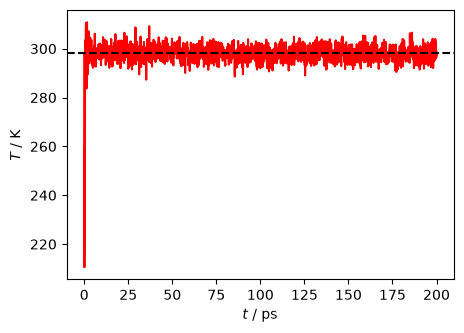

In [8]:
data = np.loadtxt('MD/nvt/temp.xvg', skiprows=24)
t = data[:,0]
T = data[:,1]
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.plot(t, T, '-r')
ax.axhline(y=298.15, linestyle='--', color='k')
ax.set_ylabel(r'$T$ / K')
ax.set_xlabel(r'$t$ / ps')

The horizontal dashed line represents the target temperature:

$$
T_\mathrm{target}=298.15\ \mathrm{K}
$$

The temperature will not be perfectly constant. Some fluctuation is expected because the atoms are continuously exchanging kinetic energy as they move and interact.

What we want to see is that the temperature initially approaches the target value and then **fluctuates around approximately 298.15 K**.

A typical temperature plot therefore looks roughly like:

```text
Temperature
    |
    |             ~~~~~~~ ~~~~~ ~~~~~
298 |------------ - - - - - - - - - -  target
    |       ~~~~
    |    ~~
    |
    +------------------------------------> time
```

The important point is that the system should settle into a stable temperature region rather than continuously drifting away from the target.

---

## 2.0.14 What does "equilibrated" mean?

Reaching 298.15 K is an important check, but temperature alone does **not** prove that the entire system is equilibrated.

Equilibration means that the system has had enough time to settle into a stable thermodynamic state appropriate for the chosen simulation conditions.

For the NVT stage, we therefore want to check that:

* the temperature has reached approximately 298.15 K;
* the temperature fluctuates around the target rather than continuously drifting;
* the potential energy has stabilized;
* there are no obvious structural problems in the trajectory.

For a liquid system such as Py-Et-Py in acetonitrile, it is also useful to visually inspect the trajectory to make sure that the solvent and solute behave normally.

Once the NVT stage is behaving as expected, the system can be taken to the next equilibration stage, for example **NPT equilibration**, if the simulation protocol requires the pressure and density to be equilibrated as well.

# 3.0 NPT Equilibration

After NVT equilibration, the system has been brought to the desired temperature of **298.15 K**, but the simulation box is still fixed at the size chosen during system preparation.

For a liquid simulation, we also want the **density** to reach a physically appropriate value. To allow the simulation box to adjust its volume, we now perform an **NPT equilibration**.

NPT stands for:

* **N** = constant number of particles
* **P** = constant pressure
* **T** = constant temperature

During this stage, the temperature is maintained at **298.15 K**, while the pressure is maintained at **1 bar**. Unlike NVT, the simulation box is allowed to expand or contract. This allows the liquid density to relax toward its equilibrium value.

For acetonitrile, the experimental density at approximately room temperature is around **0.782 g cm⁻³**, or equivalently:

$$
0.782\ \mathrm{g\,cm^{-3}} = 782\ \mathrm{kg\,m^{-3}}
$$

The NPT simulation therefore allows us to check whether our model reproduces a reasonable liquid density.

---

## 3.0.1 NPT parameter file

The NPT simulation uses the following `npt.mdp` file:

```text
; Run parameters
integrator            = md          ; leap-frog integrator
dt                    = 0.001       ; time step length (ps)
nsteps                = 200000      ; number of steps
continuation          = yes         ; continue from previous simulation

; Output control
nstenergy             = 100         ; steps between saving energies
nstlog                = 100         ; steps between saving log information
nstxout-compressed    = 100         ; steps between saving compressed coordinates

; Bond parameters
constraint_algorithm  = lincs
constraints            = h-bonds    ; constrain bonds involving hydrogen
lincs_iter             = 1          ; number of LINCS iterations
lincs_order            = 4          ; order of the LINCS expansion

; Neighbor searching
cutoff-scheme         = Verlet
rcoulomb              = 1.2         ; short-range electrostatic cutoff (nm)
rvdw                  = 1.2         ; short-range van der Waals cutoff (nm)
rlist                 = 1.2         ; short-range neighbor-list cutoff (nm)

; Electrostatics
coulombtype           = PME         ; Particle Mesh Ewald
pme_order             = 4           ; interpolation order
fourierspacing        = 0.16        ; FFT grid spacing (nm)

; Temperature coupling
tcoupl                = v-rescale   ; temperature coupling
tc-grps               = system      ; couple the entire system
tau_t                 = 0.5         ; temperature coupling time (ps)
ref_t                 = 298.15      ; reference temperature (K)

; Pressure coupling
pcoupl                = C-rescale   ; pressure coupling
pcoupltype             = isotropic   ; uniform scaling of the box
tau_p                  = 5.0         ; pressure coupling time (ps)
ref_p                  = 1.0         ; reference pressure (bar)
compressibility        = 10.07e-5    ; isothermal compressibility of ACN (bar^-1)
;refcoord_scaling      = com

; Periodic boundary conditions
pbc                   = xyz         ; 3-D periodic boundary conditions

; Dispersion correction
DispCorr              = EnerPres     ; correction for truncated vdW interactions

; Velocity generation
gen_vel               = no          ; use velocities from the NVT simulation
```

Most of the parameters are the same as those used during NVT equilibration. The main difference is that **pressure coupling is now switched on**.

---

## 3.0.2 Continuing from the NVT simulation

The simulation uses:

```text
continuation = yes
```

because the NPT simulation is a continuation of the previous NVT equilibration.

The NPT simulation starts from:

```text
nvt/nvt.gro
```

and therefore uses the final coordinates produced by the NVT simulation.

We also use:

```text
gen_vel = no
```

This is important because we do not want to generate a completely new set of velocities. Instead, the NPT simulation continues with the velocities obtained at the end of the NVT stage.

The overall progression is therefore:

```text
Energy minimization
        |
        v
       NVT
  T = 298.15 K
  V = constant
        |
        v
       NPT
  T = 298.15 K
  P = 1 bar
  V = allowed to change
```

---

## 3.0.3 Temperature coupling

The temperature coupling parameters are:

```text
tcoupl   = v-rescale
tc-grps  = system
tau_t    = 0.5
ref_t    = 298.15
```

As in the NVT simulation, the `v-rescale` thermostat is used to control the temperature.

The target temperature is:

```text
ref_t = 298.15
```

so the system is maintained around **298.15 K**.

The temperature coupling time has now been changed to:

```text
tau_t = 0.5
```

This means that the temperature coupling is somewhat less aggressive than in the NVT stage. The system has already been brought close to the target temperature during NVT, so the thermostat does not need to make large corrections.

---

## 3.0.4 Pressure coupling

The important new part of the NPT simulation is pressure coupling:

```text
pcoupl       = C-rescale
pcoupltype   = isotropic
tau_p        = 5.0
ref_p        = 1.0
```

The pressure is controlled using the `C-rescale` pressure-coupling method.

```text
pcoupltype = isotropic
```

means that the simulation box is scaled **uniformly in all three directions**.

For example, if the system needs to increase its volume, the lengths of the three box vectors are increased together. This is appropriate for a liquid where we do not want to impose a preferred direction.

The target pressure is:

```text
ref_p = 1.0
```

which corresponds to **1 bar**.

---

## 3.0.5 Pressure coupling time

```text
tau_p = 5.0
```

is the pressure coupling time constant, in ps.

It controls how quickly the simulation box responds to differences between the instantaneous pressure and the target pressure.

A relatively long coupling time avoids making very rapid changes to the box dimensions. This is useful because the box should gradually adjust while the liquid relaxes.

---

## 3.0.6 Isothermal compressibility

One important parameter for pressure coupling is:

```text
compressibility = 10.07e-5
```

with units of:

$$
\mathrm{bar^{-1}}
$$

This is the **isothermal compressibility** used by the pressure-coupling algorithm.

In simple terms, compressibility describes how much the volume of a material changes when its pressure changes.

Liquids are relatively difficult to compress, so their volume does not change very much when the pressure changes.

Because this simulation contains acetonitrile as the solvent, the value used here corresponds to the assumed compressibility of acetonitrile.

> **Important:** the compressibility should be appropriate for the solvent/model being simulated. If you change the solvent, this value should be reconsidered.

---

## 3.0.7 Running the NPT simulation

First, we prepare the NPT input file using:

```bash
gmx grompp -f npt.mdp -c nvt/nvt.gro -p topol.top -o npt/npt -maxwarn 1
```

The options are:

* `-f npt.mdp` — NPT simulation parameters.
* `-c nvt/nvt.gro` — final structure from the NVT simulation.
* `-p topol.top` — system topology.
* `-o npt/npt` — output filename prefix.
* `-maxwarn 1` — allows GROMACS to proceed despite one warning from `grompp`.

The `-maxwarn` option should be used with caution. A warning from `grompp` can indicate a real problem with the simulation setup, so it is better to understand the warning before deciding that it is safe to override it.

We then run the simulation:

```bash
gmx mdrun -v -deffnm npt/npt
```

The NPT simulation lasts:

$$
200000 \times 0.001\ \mathrm{ps}
= 200\ \mathrm{ps}
$$

so this stage provides another **200 ps of equilibration**.

---

# 3.0.8 Checking the density

One of the most important quantities to monitor during NPT equilibration is the **density**.

Because pressure coupling allows the simulation box to change volume, the density can change during the simulation.

We can extract the density from the energy file with:

```bash
echo 23 | gmx energy -f npt/npt.edr -o npt/density.xvg
```

Here, `23` is the menu number corresponding to **Density** in the particular energy-output list.

It is worth checking the menu each time rather than assuming that Density will always be item 23, because the numbering can depend on the GROMACS version and the available energy terms.

The resulting file contains the density as a function of time.

---

## 3.0.9 Plotting the density

We can plot the density using Python:

Text(0.5, 0, '$t$ / ps')

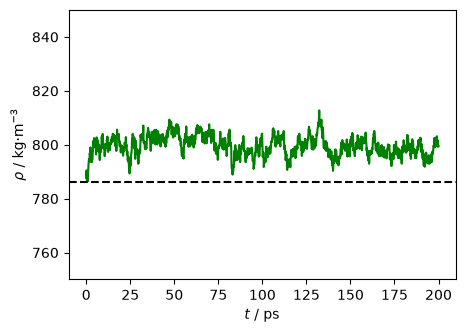

In [12]:
data = np.loadtxt('MD/npt/density.xvg', skiprows=24)
t = data[:,0]
rho = data[:,1]
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.plot(t, rho, '-g')
ax.axhline(y=786, linestyle='--', color='k')
ax.set_ylim([750, 850])
ax.set_ylabel(r'$\rho$ / kg$\cdot$m$^{-3}$')
ax.set_xlabel(r'$t$ / ps')

The horizontal dashed line represents the reference density:

$$
\rho_\mathrm{ACN} \approx 782\ \mathrm{kg\,m^{-3}}
$$

The density will generally fluctuate because the liquid is constantly moving. Therefore, we should not expect the curve to become perfectly flat.

Instead, we are looking for the density to **settle into a stable region and fluctuate around a roughly constant average value**.

A schematic example would look like:

```text
Density
  |
850 |       \
    |        \       ~~~ ~~~ ~~~~
    |         \_____/             ~~~
782 |----------------------------------  reference
    |                     ~~~ ~~~
750 |
    +------------------------------------> time
             equilibration
```

The most important feature is not that every point is exactly 782 kg m⁻³, but that the density stops showing a systematic increase or decrease.

---

# 3.0.10 Checking whether the density has converged

During NPT equilibration, the simulation box is initially based on our estimated density. The pressure coupling then allows the box to change until the system reaches a more appropriate volume.

For example:

* If the initial density is too low, the box may shrink and the density will increase.
* If the initial density is too high, the box may expand and the density will decrease.
* Eventually, the density should fluctuate around a relatively stable average.

Therefore, when looking at the density plot, we want to ask:

> **Has the density stopped drifting and reached a stable average?**

This is more informative than simply asking whether the density happens to cross the experimental value at some point.

We should also check the **pressure** and **temperature**. Instantaneous pressure can fluctuate considerably in molecular dynamics, particularly for relatively small systems, so large short-term fluctuations do not necessarily indicate a problem. The important quantity is the average behavior over an appropriate time interval.

---

## 3.0.11 Checking the pressure

The pressure can be extracted in the same way:

```bash
gmx energy -f npt/npt.edr -o npt/pressure.xvg
```

Select **Pressure** from the list of available quantities.

We can then plot it using the same procedure:

```python
data = np.loadtxt('MD/npt/pressure.xvg', skiprows=24)

t = data[:, 0]
P = data[:, 1]

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))

ax.plot(t, P, alpha=0.3)
ax.axhline(y=1.0, linestyle='--')

ax.set_ylabel(r'$P$ / bar')
ax.set_xlabel(r'$t$ / ps')

plt.show()
```

The target pressure is:

$$
P_\mathrm{target}=1\ \mathrm{bar}
$$

The instantaneous pressure can fluctuate strongly around this value. Therefore, the goal is not to obtain a perfectly flat line at 1 bar, but rather for the **average pressure over a sufficiently long time interval to be consistent with the target pressure**.

---

## 3.0.12 What should we check before production MD?

At the end of NPT equilibration, we want the system to be reasonably stable before using it for production MD.

At minimum, we should inspect:

1. **Temperature** — does it remain close to 298.15 K?
2. **Pressure** — does the average behavior approach the target pressure of 1 bar?
3. **Density** — has the density reached a stable average?
4. **Potential energy** — has the energy stopped showing a systematic drift?
5. **Trajectory** — does the molecular structure look physically reasonable?

For the density, we can compare the average value from the equilibrated part of the trajectory with the experimental reference value used for comparison:

$$
\rho_\mathrm{exp} \approx 782\ \mathrm{kg\,m^{-3}}
$$

However, the density of the **Py-Et-Py + acetonitrile mixture** is not necessarily identical to the density of pure acetonitrile. Therefore, the pure-ACN value should be treated as a reference for the solvent rather than as an exact expected value for the entire mixture.

If the density is still steadily increasing or decreasing at the end of the 200 ps simulation, the system may need a longer equilibration period before production MD.

---

## 3.0.13 Overall equilibration workflow

At this point, our simulation protocol is:

```text
Initial structure
       |
       v
Energy minimization
Remove unfavorable contacts
       |
       v
NVT equilibration
T = 298.15 K
V = constant
       |
       v
NPT equilibration
T = 298.15 K
P = 1 bar
V = allowed to change
       |
       v
Check:
  - Temperature
  - Pressure
  - Density
  - Potential energy
  - Structure
       |
       v
Production MD
```

The key difference between NVT and NPT is therefore the **volume**:

```text
NVT:
Temperature controlled
Volume fixed
Pressure not controlled

NPT:
Temperature controlled
Pressure controlled
Volume allowed to change
```

The NPT stage is particularly important for a liquid system because it allows the simulation box to find a volume consistent with the chosen pressure and the force-field description of the liquid.


# 3.0 Production MD

After energy minimization, NVT equilibration, and NPT equilibration, the system should be in a physically reasonable state. We can now perform the **production molecular dynamics (MD) simulation**.

The production run is the part of the simulation from which we collect the data we actually want to analyse. Unlike the equilibration stages, the goal here is not primarily to prepare the system, but to generate a sufficiently long trajectory for calculating properties and studying the molecular behavior of Py-Et-Py in acetonitrile.

For the production simulation, we will use a **computing cluster** rather than running the simulation directly on a personal computer. The cluster allows us to use many CPU cores and run the simulation efficiently.

---

## 3.0.1 Running the simulation on the cluster

Cluster calculations are usually managed by a **job scheduler**. Here we use **SLURM**, which controls when and where the calculation is run and allocates the requested computational resources.

The production job is submitted using a SLURM script:

```bash id="w6qj4k"
#!/bin/bash

#SBATCH --job-name=Py_Et_Py_ACN_prod
#SBATCH --output=slurm-%J.out
#SBATCH --error=slurm-%J.err
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
#SBATCH --time=00-4:00:00
#SBATCH --partition=shared-cpu

module load GCC/11.3.0 CUDA/11.4.1 OpenMPI/4.1.4 GROMACS/2023.1

gmx grompp -f prod.mdp -c npt/npt.gro -p topol.top -o prod/prod
gmx mdrun -nt 32 -v -deffnm prod/prod
```

The first line:

```bash
#!/bin/bash
```

specifies that the script should be interpreted using the Bash shell.

The lines beginning with `#SBATCH` tell SLURM what resources we need and how the job should be handled.

---

## 3.0.2 SLURM settings

```bash id="y9f5fp"
#SBATCH --job-name=Py_Et_Py_ACN_prod
```

This gives the job a recognizable name. This is useful when several simulations are running on the cluster at the same time.

```bash id="x3x6rf"
#SBATCH --output=slurm-%J.out
#SBATCH --error=slurm-%J.err
```

These specify where standard output and error messages should be written.

`%J` is replaced by the SLURM job ID, so each job gets its own output and error file.

```bash id="ak8s8q"
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
```

These settings request:

* **1 node** — one physical computer within the cluster.
* **1 task** — one main MPI task.
* **32 CPU cores** — the task can use 32 CPU cores.

The number of cores is then explicitly passed to GROMACS later using:

```bash
gmx mdrun -nt 32
```

---

## 3.0.3 Maximum wall-clock time

```bash id="p1k4hc"
#SBATCH --time=00-4:00:00
```

This requests a maximum wall-clock time of **4 days**.

This is different from the simulated time. The MD simulation itself represents **10 ns of physical time**, but it may take many hours or days of real computer time to calculate those 10 ns.

For example:

```text
Simulation time:       10 ns
Computer time:         potentially several hours/days
```

The amount of real time required depends on the system size, hardware, number of CPU cores, and simulation settings.

---

## 3.0.4 Selecting the cluster partition

```bash id="s6yq0a"
#SBATCH --partition=shared-cpu
```

This tells SLURM which partition (queue) should be used.

The exact partition names and their resource limits depend on the cluster being used.

---

## 3.0.5 Loading GROMACS

Before running GROMACS, we load the required software modules:

```bash id="nq8n4j"
module load GCC/11.3.0 CUDA/11.4.1 OpenMPI/4.1.4 GROMACS/2023.1
```

Clusters typically have many different software versions installed. The `module load` command makes the required versions available in the current environment.

Here we load:

* GCC 11.3.0
* CUDA 11.4.1
* OpenMPI 4.1.4
* GROMACS 2023.1

The exact modules required depend on how GROMACS was installed on the particular cluster.

---

# 3.0.6 Preparing and running the production simulation

The production simulation starts from the final structure obtained during NPT equilibration:

```text id="x4u2tt"
npt/npt.gro
```

First, we prepare the GROMACS input file:

```bash id="iq6h8a"
gmx grompp -f prod.mdp -c npt/npt.gro -p topol.top -o prod/prod
```

Here:

* `-f prod.mdp` — production MD parameters.
* `-c npt/npt.gro` — final coordinates from NPT equilibration.
* `-p topol.top` — system topology.
* `-o prod/prod` — output filename prefix.

This produces the `.tpr` file required by `mdrun`.

We then start the actual simulation:

```bash id="6qv7qp"
gmx mdrun -nt 32 -v -deffnm prod/prod
```

The options are:

* `-nt 32` — use 32 CPU threads.
* `-v` — provide verbose progress information.
* `-deffnm prod/prod` — use `prod/prod` as the default filename prefix.

The resulting files contain the trajectory, energies, log information, and other data needed for subsequent analysis.

---

# 3.0.7 Production MD parameters

The production simulation uses the following `prod.mdp` file:

```text id="4q7b8x"
; Run parameters
integrator            = md          ; leap-frog integrator
dt                    = 0.001       ; time step length (ps)
nsteps                = 10000000    ; number of steps

continuation           = yes

; Output control
nstenergy             = 2000        ; steps between saving energies
nstlog                = 2000        ; steps between saving log information
nstxout-compressed    = 2000        ; steps between saving compressed coordinates

; Bond parameters
constraint_algorithm  = lincs
constraints            = h-bonds     ; constrain bonds involving hydrogen
lincs_iter             = 1          ; number of LINCS iterations
lincs_order            = 4          ; order of the LINCS expansion

; Neighbor searching
ns_type               = grid
nstlist               = 10          ; neighbor-list update frequency
rcoulomb              = 1.2         ; short-range electrostatic cutoff (nm)
rvdw                  = 1.2         ; short-range van der Waals cutoff (nm)
rlist                 = 1.2         ; short-range neighbor-list cutoff (nm)

; Electrostatics
coulombtype           = PME         ; Particle Mesh Ewald
pme_order             = 4           ; interpolation order
fourierspacing        = 0.16        ; FFT grid spacing (nm)

; Temperature coupling
tcoupl                = Nose-Hoover ; Nose-Hoover thermostat
tc-grps               = system
tau_t                 = 0.5         ; temperature coupling time (ps)
ref_t                 = 298.15      ; reference temperature (K)

; Pressure coupling
pcoupl                = C-rescale   ; pressure coupling
pcoupltype            = isotropic   ; uniform scaling of box vectors
tau_p                 = 5.0         ; pressure coupling time (ps)
ref_p                 = 1.0         ; reference pressure (bar)
compressibility       = 10.07e-5    ; isothermal compressibility of ACN (bar^-1)

; Periodic boundary conditions
pbc                   = xyz         ; 3-D periodic boundary conditions

; Dispersion correction
DispCorr              = EnerPres     ; correction for truncated vdW interactions

; Velocity generation
gen_vel               = no          ; use velocities from the previous simulation
```

The production simulation retains the same basic physical conditions established during equilibration:

$$
T = 298.15\ \mathrm{K}
$$

and

$$
P = 1\ \mathrm{bar}.
$$

The important difference is that we are now running the simulation for a much longer period in order to collect meaningful trajectory data.

---

## 3.0.8 Simulation length

The time step is:

```text id="zv0s4r"
dt = 0.001
```

Since GROMACS uses ps for the time unit here:

$$
0.001\ \mathrm{ps}=1\ \mathrm{fs}.
$$

The simulation contains:

```text id="g3bq1e"
nsteps = 10000000
```

steps.

Therefore, the total simulated time is:

$$
10\,000\,000 \times 0.001\ \mathrm{ps}
=10\,000\ \mathrm{ps}
=10\ \mathrm{ns}.
$$

Thus, the production simulation covers **10 ns of physical simulation time**.

This is much longer than the 200 ps equilibration stages:

```text
Energy minimization
        |
        v
NVT:       200 ps
        |
        v
NPT:       200 ps
        |
        v
Production: 10 ns
```

The equilibration stages prepare the system, whereas the production trajectory is the main source of data for subsequent analysis.

---

# 3.0.9 Saving trajectory and energy data

The production run does not need to save data at every single MD step. Doing so would generate unnecessarily large files.

Instead:

```text id="r0ocpj"
nstenergy          = 2000
nstlog             = 2000
nstxout-compressed = 2000
```

Since each MD step is 0.001 ps, 2000 steps correspond to:

$$
2000\times0.001\ \mathrm{ps}
=2\ \mathrm{ps}.
$$

Therefore, energy information, log information, and compressed coordinates are saved every **2 ps**.

For a 10 ns simulation, this provides a trajectory with approximately:

$$
\frac{10\,000\ \mathrm{ps}}{2\ \mathrm{ps}}
=5000
$$

saved trajectory frames.

This is usually much more manageable than saving all 10 million MD steps.

---

# 3.0.10 Thermostat during production

The production simulation uses:

```text id="7l0o4w"
tcoupl = Nose-Hoover
```

The **Nose-Hoover thermostat** is used to maintain the system close to the target temperature of 298.15 K.

Unlike the `v-rescale` thermostat used during the previous equilibration stages, Nose-Hoover is commonly used when one wants to generate a trajectory with more appropriate canonical-ensemble dynamics after the system has already been equilibrated.

The temperature settings are:

```text id="5l8w9e"
tc-grps = system
tau_t   = 0.5
ref_t   = 298.15
```

The entire system is coupled to the thermostat, with a target temperature of 298.15 K.

---

# 3.0.11 Pressure coupling during production

The production simulation also retains pressure coupling:

```text id="4ak5yd"
pcoupl     = C-rescale
pcoupltype = isotropic
tau_p      = 5.0
ref_p      = 1.0
```

Thus, the production simulation continues under approximately:

$$
P=1\ \mathrm{bar}.
$$

The box is allowed to change its volume as required by the pressure coupling.

This means that the production simulation is still being performed under **NPT conditions**, rather than NVT conditions.

---

## 3.0.12 Use the compressibility of your solvent

One particularly important parameter is:

```text id="2jnd2n"
compressibility = 10.07e-5
```

The value above is appropriate for the acetonitrile system used here.

If you change the solvent, you should **replace this value with the appropriate isothermal compressibility for your solvent and simulation conditions**.

In other words, do not simply copy the acetonitrile value into a simulation containing a different solvent.

The compressibility tells the pressure-coupling algorithm how strongly the solvent volume responds to changes in pressure. Using an inappropriate value can therefore affect the behavior of the NPT simulation.

---

# 3.0.13 No new velocities are generated

Finally:

```text id="z6t5l1"
gen_vel = no
```

means that no new velocities are generated at the beginning of the production run.

The simulation instead continues from the velocities generated and equilibrated during the previous stages.

This is appropriate because we do not want to restart the thermal distribution at the beginning of the production trajectory. The production run should continue naturally from the equilibrated NPT system.

---

# 3.0.14 What is the purpose of the production run?

At this point, the system has gone through several stages:

```text id="0f5y0d"
1. Initial structure
        ↓
2. Energy minimization
        ↓
3. NVT equilibration
        ↓
4. NPT equilibration
        ↓
5. Production MD
```

Each stage has a different purpose.

**Energy minimization** removes severe unfavorable contacts and relaxes the initial structure.

**NVT equilibration** establishes the desired temperature while keeping the box volume fixed.

**NPT equilibration** allows the volume and density to relax at the desired pressure and temperature.

**Production MD** generates the trajectory that will be used for scientific analysis.

For the production run, we therefore do not primarily ask:

> "Has the system reached equilibrium?"

Instead, we want to ensure that the system remains stable and that the trajectory is sufficiently long to calculate the properties of interest.

For example, the trajectory can later be used to investigate quantities such as:

* torsional-angle distributions;
* conformational populations;
* radial distribution functions;
* diffusion;
* density;
* energy fluctuations;
* structural properties;
* solvent interactions;
* time-dependent behavior of the Py-Et-Py molecule.

The appropriate analyses depend on the scientific question being investigated.

---

## 3.0.15 Production run on the cluster

The complete workflow for submitting the production calculation is therefore:

```bash id="nq8y2m"
#!/bin/bash

#SBATCH --job-name=Py_Et_Py_ACN_prod
#SBATCH --output=slurm-%J.out
#SBATCH --error=slurm-%J.err
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=32
#SBATCH --time=00-4:00:00
#SBATCH --partition=shared-cpu

module load GCC/11.3.0 CUDA/11.4.1 OpenMPI/4.1.4 GROMACS/2023.1

gmx grompp -f prod.mdp -c npt/npt.gro -p topol.top -o prod/prod
gmx mdrun -nt 32 -v -deffnm prod/prod
```

The final production trajectory is then stored in the `prod/` directory and can be used for the subsequent analysis.

> **Note:** The production run is only as good as the equilibration that precedes it. Before analysing the 10 ns trajectory, it is therefore important to verify that the NVT and NPT stages have reached stable temperature, pressure, density, and energy behavior.


# 3. Analysis

After the production MD simulation has finished, we can start analysing the trajectory. The production trajectory contains the positions of all atoms as a function of time, so we can use it to investigate how the Py-Et-Py molecule behaves in acetonitrile.

Before calculating structural properties, it is useful to prepare the trajectory and inspect it visually.

---

## 3.1 Centering the trajectory on Py-Et-Py

Because periodic boundary conditions (PBC) are used, molecules can appear to move across the boundaries of the simulation box. For example, one part of a molecule may appear on one side of the box while another part appears on the opposite side.

This does not mean that the molecule has actually broken apart. It is simply a consequence of the periodic simulation box.

For visualization and some structural analyses, it is therefore useful to make a trajectory in which the Py-Et-Py molecule stays together and remains near the center of the simulation box.

We can do this with:

```bash
gmx trjconv -s prod/prod.tpr \
            -f prod/prod.xtc \
            -o prod/prod-mol.xtc \
            -pbc mol \
            -center
```

The important options are:

* `-s prod/prod.tpr` — provides the simulation topology and system information.
* `-f prod/prod.xtc` — the original production trajectory.
* `-o prod/prod-mol.xtc` — the new, processed trajectory.
* `-pbc mol` — handles periodic boundary conditions by keeping molecules together.
* `-center` — allows us to center the trajectory around a selected group.

GROMACS will ask which group should be used for centering and which group should be written to the output trajectory.

For this system, we select:

```text
Select group for centering = 2 (PYR)
Select group for output    = 0 (System)
```

Thus, the **Py-Et-Py molecule is used as the reference for centering**, while the complete system — Py-Et-Py plus all acetonitrile molecules — is retained in the output trajectory.

The resulting file,

```text
prod/prod-mol.xtc
```

can now be used for visualization and subsequent analyses.

> **Why do we center the molecule?**
> Without this processing step, periodic boundary conditions can make a molecule appear to jump from one side of the box to the other. Centering makes the trajectory easier to interpret visually and avoids complications for analyses that depend on molecular positions.

---

## 3.2 Visual inspection of the trajectory

Before calculating numerical properties, it is good practice to **look at the trajectory**.

We can open the trajectory in **VMD** and load the visualization settings using the TK console:

```tcl
source trajectory.sh
```

The `trajectory.sh` file contains commands that configure the VMD representation, colors, background, or other visualization settings.

We then visually inspect the trajectory.

In particular, we can check whether:

* the Py-Et-Py molecule remains intact;
* the molecule behaves continuously rather than showing unexpected jumps;
* the acetonitrile molecules behave normally;
* there are no obvious structural distortions;
* the trajectory does not contain obvious simulation artifacts.

Visual inspection is not a substitute for quantitative analysis, but it is a useful first check. It can reveal problems that might otherwise be difficult to notice from numerical data alone.

---

# 3.3 Creating an index file

For the next analysis, we are interested in the distance between the **centers of mass (COMs) of the two pyrene rings**.

To calculate this quantity, GROMACS needs to know which atoms belong to each pyrene ring.

We can create an **index file** using:

```bash
gmx make_ndx -f prod/prod.gro
```

An index file, usually called:

```text
index.ndx
```

is simply a file containing **groups of atoms that we want to use for analysis**.

You can think of it as making labeled selections of atoms.

For example, instead of repeatedly telling GROMACS:

> "Use atoms 4, 5, 6, 7, ..."

we can create a group called `PYR1` containing those atoms and another group called `PYR2` containing the atoms belonging to the second pyrene ring.

These groups can then be reused by different GROMACS analysis commands.

---

## 3.3.1 Defining the two pyrene rings

For this molecule, we define the first pyrene ring using:

```text
a 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19
```

and the second pyrene ring using:

```text
a 1 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
```

Here, `a` means **atom selection**.

Thus, the two groups contain:

```text
Pyrene ring 1:
4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19

Pyrene ring 2:
1  20 21 22 23 24 25 26 27 28 29 30 31 32 33 34
```

Once these groups have been created, they are stored in `index.ndx`.

The exact group numbers assigned by `make_ndx` depend on the groups already present in the system and the order in which the new groups are created. In the following analysis, we refer to the two groups as **group 4** and **group 5**, corresponding to the two pyrene rings.

---

# 3.4 Center-of-mass distance between the two pyrene rings

We can now calculate the distance between the centers of mass of the two pyrene-ring groups.

The GROMACS command is:

```bash
gmx distance \
    -f prod/prod-mol.xtc \
    -s prod/prod.tpr \
    -n index.ndx \
    -oav analysis/com_dist.xvg
```

The options are:

* `-f prod/prod-mol.xtc` — the centered production trajectory.
* `-s prod/prod.tpr` — the simulation structure/topology information.
* `-n index.ndx` — the index file containing our pyrene-ring groups.
* `-oav analysis/com_dist.xvg` — writes the average distance for each specified pair of positions to the output file.

GROMACS will ask us to select the groups used for the distance calculation.

We select the **COM of group 4** and the **COM of group 5**.

In other words, the calculation is:

$$
d_\mathrm{COM-COM}
=
\left|
\mathbf{R}_{\mathrm{COM},1}
-
\mathbf{R}_{\mathrm{COM},2}
\right|
$$

where $(\mathbf{R}_{\mathrm{COM},1}$ is the center-of-mass position of the first pyrene ring and $\mathbf{R}_{\mathrm{COM},2}$ is the center-of-mass position of the second pyrene ring.

---

## 3.4.1 What is a center of mass?

The **center of mass (COM)** is the mass-weighted average position of all atoms in a group.

For a group containing \(N\) atoms, it is given by:

$$
\mathbf{R}_{\mathrm{COM}}
=
\frac{\sum_i m_i\mathbf{r}_i}
{\sum_i m_i}
$$

where:

* $m_i$ is the mass of atom $i$;
* $\mathbf{r}_i$ is the position of atom $i$.

In simple terms, we can think of the COM as the point at which the whole group could be considered to be concentrated for the purpose of describing its overall position.

For each pyrene ring, GROMACS calculates this point and then measures the distance between the two points.

---

## 3.4.2 What does the COM–COM distance tell us?

The COM–COM distance provides a simple measure of how far apart the two pyrene rings are during the simulation.

For example:

```text
Small COM–COM distance
        ↓
   rings are closer
        ↓
      Py-Et-Py
```

whereas a larger distance indicates that the two rings have moved farther apart.

Because Py-Et-Py is torsionally flexible, this distance can change as the molecule changes conformation.

Therefore, the COM–COM distance gives us a convenient way to monitor the **overall separation of the two pyrene moieties as a function of time**.

However, it is important to remember that the COM–COM distance describes only one aspect of the molecular conformation. Two conformations can have a similar COM–COM distance while having different orientations or torsional angles.

For a more complete description of the molecular conformations, we can therefore combine this analysis with quantities such as the relevant **dihedral angles**.

---

## 3.4.3 Output

The calculated distance is stored in:

```text
analysis/com_dist.xvg
```

This file contains the COM–COM distance as a function of simulation time and can subsequently be plotted with Python.


Text(0.5, 0, '$t$ / ps')

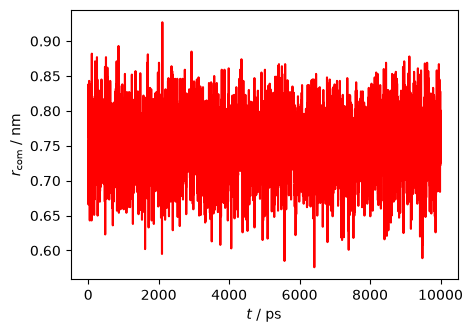

In [5]:
data = np.loadtxt('MD/analysis/com_dist.xvg', skiprows=24)
t = data[:,0]
r_com = data[:,1]
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.plot(t, r_com, '-r')
ax.set_ylabel(r'$r_\mathrm{com}$ / nm')
ax.set_xlabel(r'$t$ / ps')

From this we can also make a histogram:

Text(0.5, 0, '$r_\\mathrm{com}$ / nm')

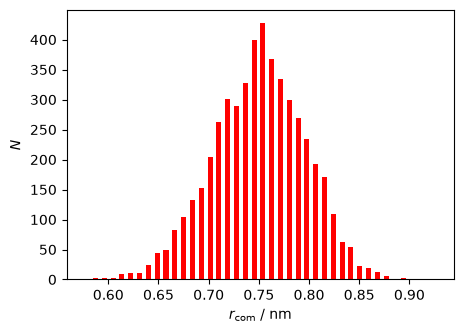

In [6]:
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.hist(r_com, 40, color='r', width=0.005)
ax.set_ylabel(r'$N$')
ax.set_xlabel(r'$r_\mathrm{com}$ / nm')

We can also look at the **distribution of the 1–2–3–4 dihedral angle** over the production trajectory. This allows us to see which torsional conformations are sampled most frequently during the simulation.

Again, we first create an index group containing the four atoms that define the dihedral:

```bash
gmx make_ndx -f prod/prod.gro -o index.ndx
```

Inside the `make_ndx` prompt, enter:

```text
a 1 2 3 4
name 4 DIHEDRAL_1_2_3_4
q
```

The group number (`4` in this example) may be different depending on the groups already present in your index file. The important point is that the group contains the four atoms **1, 2, 3, and 4 in this order**.

We can then calculate the dihedral angle for every frame of the trajectory using `gmx angle` with the `-type dihedral` option:

```bash
gmx angle \
    -f prod/prod-mol.xtc \
    -n index.ndx \
    -type dihedral \
    -ov analysis/dihedral_1-2-3-4.xvg
```

When prompted to select a group, choose the `DIHEDRAL_1_2_3_4` group.


Text(0.5, 0, '$t$ / ps')

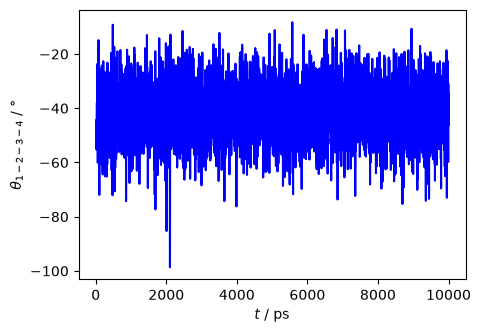

In [22]:
data = np.loadtxt('MD/analysis/dihedral_1-2-3-4.xvg', skiprows=24)
t = data[:,0]
theta = data[:,1]
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.plot(t, theta, '-b')
ax.set_ylabel(r'$\theta_\mathrm{1-2-3-4}$ / °')
ax.set_xlabel(r'$t$ / ps')

Text(0.5, 0, '$\\theta_\\mathrm{1-2-3-4}$ / °')

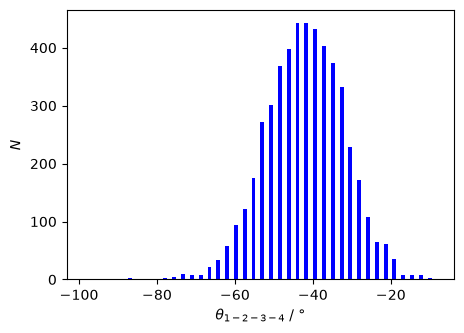

In [28]:
fig, ax = plt.subplots(1,1,figsize=(5, 3.5))
ax.hist(theta, 40, color='b', width=1)
ax.set_ylabel(r'$N$')
ax.set_xlabel(r'$\theta_\mathrm{1-2-3-4}$ / °')

If you want to **screen structures with a certain property**, you can extract the corresponding structure from the trajectory and save it as an `.xyz` or `.gro` file. Alternatively, you can simply go to the corresponding frame in VMD and take a screenshot of the structure. For example, suppose we are interested in a structure where the **1–2–3–4 dihedral angle is close to −43°**:

In [38]:
target = -43

# Find the frame closest to the target angle
i = np.argmin(np.abs(theta - target))

# Simulation time step
dt = 0.001  # ps

# Coordinates saved every 2000 MD steps
nstxout_compressed = 2000

# Time between trajectory frames
frame_dt = dt * nstxout_compressed  # 2 ps

# Corresponding trajectory frame
frame = int(round(t[i] / frame_dt))

print(f'Time = {t[i]:.2f} ps')
print(f'Frame = {frame}')
print(f'Dihedral = {theta[i]:.2f} degrees')

Time = 802.00 ps
Frame = 401
Dihedral = -43.00 degrees


Going in vmd to this frame we have: 

![dihedral](pics/dihedral.png)

To extract this specific frame from the trajectory as a `.gro` file, use:

```bash
gmx trjconv \
    -f prod/prod-mol.xtc \
    -s prod/prod.tpr \
    -o analysis/PYR_-43deg.gro \
    -dump 802
```

When prompted to select the output group, select `PYR` if you only want the Py_Et_Py molecule.

The `-dump 802` option tells GROMACS to extract the trajectory frame closest to **802 ps**. The resulting structure is written to:

```text
analysis/PYR_-43deg.gro
```

You can then open this structure in VMD and inspect it visually.

If you are working in the **VeloxChem conda environment**, you can also use VeloxChem tools to read and visualize the extracted structure directly in a Jupyter notebook. This is particularly convenient if you want to screen many structures with different dihedral angles or COM distances, since the structures can be loaded, displayed, and exported as `.xyz` files directly from the notebook.

In [1]:
import veloxchem as vlx

/Users/wega/miniconda3/envs/vlxenv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
molecule = vlx.Molecule.read_gro_file('MD/analysis/PYR_-43deg.gro')
molecule.show()
# save as xyz for example 
molecule.write_xyz_file('MD/analysis/PYR_-43deg.xyz')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Let's compare with the most like COM structure: 

In [7]:
target = 0.75

# Find the frame closest to the target angle
i = np.argmin(np.abs(r_com - target))

# Simulation time step
dt = 0.001  # ps

# Coordinates saved every 2000 MD steps
nstxout_compressed = 2000

# Time between trajectory frames
frame_dt = dt * nstxout_compressed  # 2 ps

# Corresponding trajectory frame
frame = int(round(t[i] / frame_dt))

print(f'Time = {t[i]:.2f} ps')
print(f'Frame = {frame}')
print(f'Dihedral = {r_com[i]:.2f} degrees')

Time = 216.00 ps
Frame = 108
Dihedral = 0.75 degrees


Going in vmd to this frame we have: 

![dihedral](pics/rcom.png)